# Phase 1: Interim Progress Demonstration

This notebook demonstrates the core Computer Vision pipeline for the CM4609 IRP project, fulfilling the interim progress presentation requirements.

**Objectives demonstrated:**
1. Data Pipeline: 2D Video to Frames (Completed offline).
2. 3D Camera Poses tracking (Completed via COLMAP).
3. **Core Algorithm**: Initializing the 2D Segmentation Mask on the Buddha statue using MobileSAM. This serves as the foundation for the 3D Radiance Field segmentation via SA3D.

In [1]:
import os
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np

# Add MobileSAM to path if downloaded locally
import sys
sys.path.append('MobileSAM')

from mobile_sam import sam_model_registry, SamPredictor

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.7.1+cu118
CUDA available: True


d:\Sansarana\.venv_nerf\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
d:\Sansarana\.venv_nerf\lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
d:\Sansarana\MobileSAM\mobile_sam\modeling\tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
d:\Sansarana\MobileSAM\mobile_sam\modeling\tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m_224 in registry with mobile_s

### Initializing MobileSAM
We use MobileSAM for faster inference while keeping the segmentation capability of the original Segment Anything Model.

In [2]:
model_type = "vit_t"
sam_checkpoint = "MobileSAM/weights/mobile_sam.pt"

# Ensure the weights exist (we will download them if not)
if not os.path.exists(sam_checkpoint):
    print("Downloading MobileSAM weights...")
    import urllib.request
    os.makedirs('MobileSAM/weights', exist_ok=True)
    urllib.request.urlretrieve("https://github.com/ChaoningZhang/MobileSAM/raw/master/weights/mobile_sam.pt", sam_checkpoint)
    print("Downloaded.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading model to {device}...")

mobile_sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
mobile_sam.to(device=device)
mobile_sam.eval()

predictor = SamPredictor(mobile_sam)
print("MobileSAM initialized!")

Loading model to cuda...
MobileSAM initialized!


### Loading Extracted Frame
Loading a single frame from the 'seated' dataset.

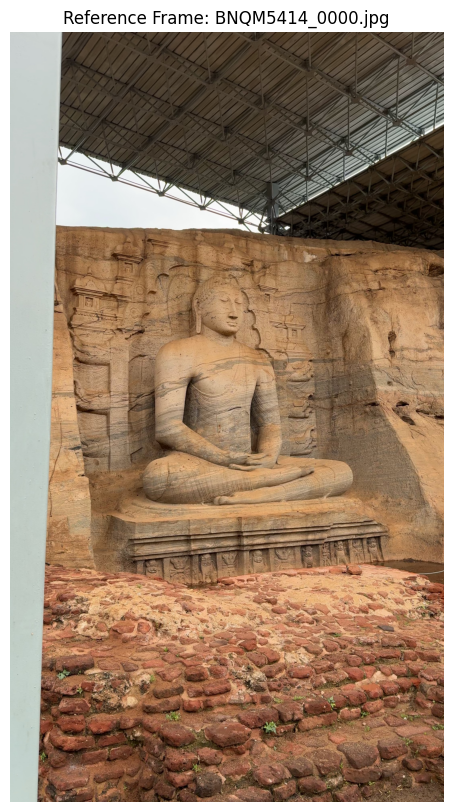

In [3]:
# Get the first available image
image_dir = r"d:\Sansarana\gal_vihara_dataset\seated\images"
images = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
image_path = os.path.join(image_dir, images[0])

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.title(f"Reference Frame: {images[0]}")
plt.show()

### Prompting the Model
We provide a point exactly on the Buddha statue to act as a prompt for the model. From this single click, MobileSAM will generate the full 2D mask footprint.

### Segmenting Request
Assuming the point is exactly in the middle of the frame.

In [4]:
predictor.set_image(image)

h, w, _ = image.shape
input_point = np.array([[w // 2, h // 2]])
input_label = np.array([1]) # Positive Prompt

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

# Choose the mask with the highest score
best_mask = masks[np.argmax(scores)]

### Apply Mask and Blur Background

Mask saved as seated_buddha_manual_mask.png


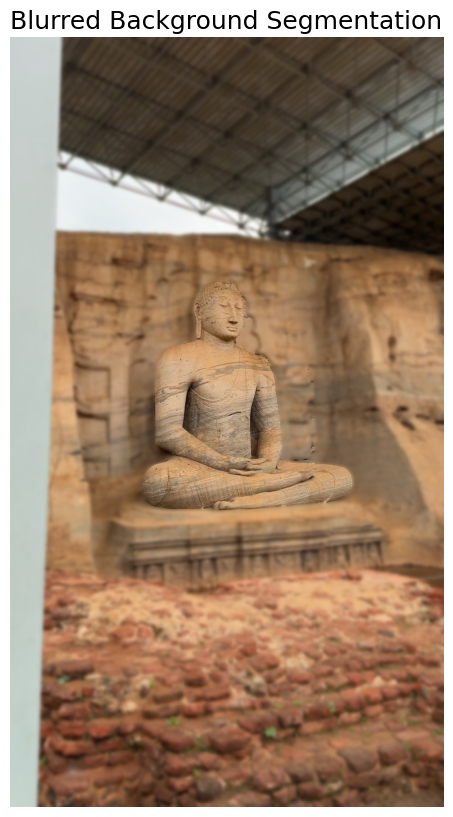

In [5]:
import cv2
from PIL import Image

# Save the finalized mask explicitly
if best_mask is not None:
    mask_to_save = (best_mask * 255).astype(np.uint8)
    Image.fromarray(mask_to_save).save("seated_buddha_manual_mask.png")
    print("Mask saved as seated_buddha_manual_mask.png")

    # Composite logic: Blurred background, unblurred segmented region
    mask = best_mask.astype(np.uint8)[:, :, np.newaxis]
    blurred_bg = cv2.GaussianBlur(image, (51, 51), 0)
    final_image = np.where(mask == 1, image, blurred_bg)

    # Convert back to inline for this plot (to avoid widget interaction in next cells)
    %matplotlib inline
    plt.figure(figsize=(10, 10))
    plt.imshow(final_image)
    plt.axis('off')
    plt.title("Blurred Background Segmentation", fontsize=18)
    plt.show()
else:
    print("No mask was generated.")

### Video Segmentation
Process a short video clip (reduced to a few frames for performance) and apply the blurred background effect frame-by-frame.

In [6]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Video paths
video_in_path = r"d:\Sansarana\gal_vihara_dataset\seated\BNQM5414.MP4"
video_out_path = r"d:\Sansarana\seated_blurred_output.mp4"

cap = cv2.VideoCapture(video_in_path)

if not cap.isOpened():
    print("Cannot open video")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0 or np.isnan(fps):
        fps = 30.0
    width_in  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height_in = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # We will process 15 frames to demonstrate the pipeline quickly.
    max_frames_to_process = 600
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(video_out_path, fourcc, fps, (width_in, height_in))
    
    print(f"Processing up to {max_frames_to_process} frames from video...")
    frame_count = 0
    
    while cap.isOpened() and frame_count < max_frames_to_process:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Convert BGR to RGB for MobileSAM processing
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        predictor.set_image(rgb_frame)
        
        # Center point prompt
        input_point = np.array([[width_in // 2, height_in // 2]])
        input_label = np.array([1])
        
        masks, scores, logits = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            multimask_output=True,
        )
        
        # Best mask
        best_mask_idx = np.argmax(scores)
        best_mask = masks[best_mask_idx]
        
        # Composite Logic
        mask = best_mask.astype(np.uint8)[:, :, np.newaxis]
        blurred_bg = cv2.GaussianBlur(frame, (51, 51), 0)
        final_frame = np.where(mask == 1, frame, blurred_bg)
        
        out.write(final_frame)
        frame_count += 1

    cap.release()
    out.release()
    print(f"Finished processing {frame_count} frames. Output saved to: {video_out_path}")


Processing up to 600 frames from video...
Finished processing 600 frames. Output saved to: d:\Sansarana\seated_blurred_output.mp4
